
>>>dataset: Celeb-DF...

>>>dataset: DFD...

DATASET         | ACC      | AUC      | PRECISION  | F1      
-----------------------------------------------------------------
Celeb-DF        | 0.9291 | 0.6824 | 0.9639    | 0.9630
DFD             | 0.8940 | 0.6062 | 0.9478    | 0.9438


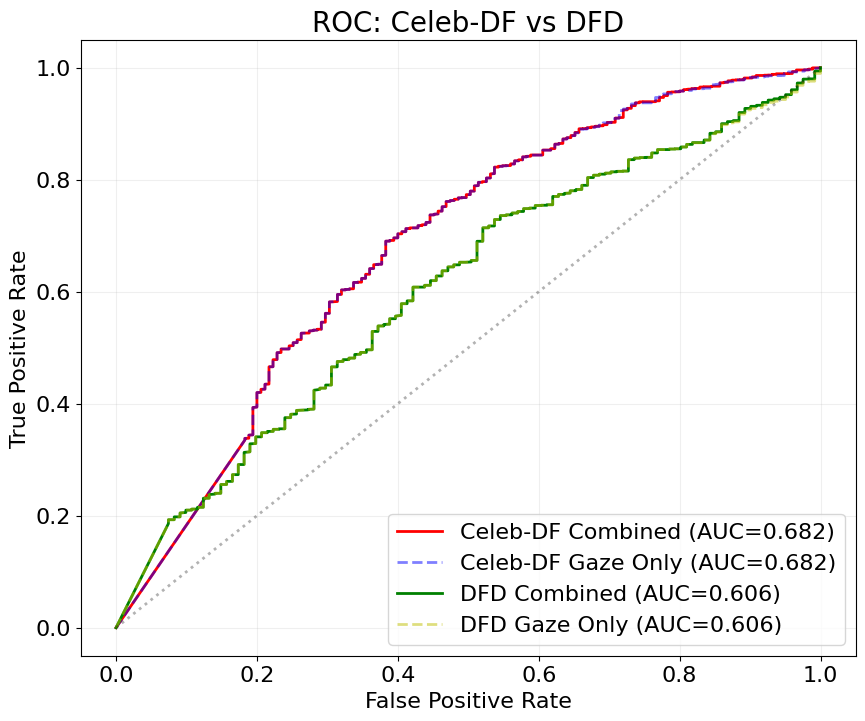

In [1]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.ndimage import label
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, f1_score
import matplotlib.pyplot as plt

fps = 30
au_cols = ['au12', 'au6', 'au15', 'au1', 'au4']
gaze_features = ['gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z']

me_weights = {
    'mean_intensity': 4.0,
    'std_intensity': 2.0,
    'frequency': 1.0,
    'max_intensity': 2.0,
    'count': 5.0
}

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "lines.linewidth": 2
})

def get_xy(df, idx):
    return df[f'x_{idx}'], df[f'y_{idx}']

def compute_au12(df):
    x48, y48 = get_xy(df, 48); x54, y54 = get_xy(df, 54)
    x0, _ = get_xy(df, 0); x16, _ = get_xy(df, 16)
    fw = np.abs(x16 - x0).replace(0, np.nan)
    mw = np.abs(x54 - x48) / fw
    _, y30 = get_xy(df, 30)
    lift = -((y48 + y54) / 2 - y30) / fw
    return 0.6 * mw + 0.4 * lift

def compute_au6(df):
    _, y27 = get_xy(df, 27); _, y30 = get_xy(df, 30)
    nl = np.abs(y30 - y27).replace(0, np.nan)
    _, y37 = get_xy(df, 37); _, y38 = get_xy(df, 38)
    _, y40 = get_xy(df, 40); _, y41 = get_xy(df, 41)
    left = ((y40 + y41) / 2) - ((y37 + y38) / 2)
    _, y43 = get_xy(df, 43); _, y44 = get_xy(df, 44)
    _, y46 = get_xy(df, 46); _, y47 = get_xy(df, 47)
    right = ((y46 + y47) / 2) - ((y43 + y44) / 2)
    return -((left + right) / 2) / nl

def compute_au15(df):
    _, y27 = get_xy(df, 27); _, y30 = get_xy(df, 30)
    nl = np.abs(y30 - y27).replace(0, np.nan)
    _, y48 = get_xy(df, 48); _, y54 = get_xy(df, 54)
    return ((y48 + y54) / 2 - y30) / nl

def compute_au1(df):
    _, y21 = get_xy(df, 21); _, y22 = get_xy(df, 22)
    _, y27 = get_xy(df, 27); _, y30 = get_xy(df, 30)
    return (y27 - (y21 + y22) / 2) / np.abs(y30 - y27).replace(0, np.nan)

def compute_au4(df):
    _, y21 = get_xy(df, 21); _, y22 = get_xy(df, 22)
    _, y27 = get_xy(df, 27); _, y30 = get_xy(df, 30)
    return ((y21 + y22) / 2 - y27) / np.abs(y30 - y27).replace(0, np.nan)

def z_normalize(df, col):
    smooth = df[col].rolling(3, center=True).mean()
    baseline = smooth.rolling(int(2 * fps), min_periods=1).median()
    delta = smooth - baseline
    return (delta - delta.mean()) / delta.std() if delta.std() != 0 else delta * 0

def extract_events(active_mask, df, peak_cols):
    events = []
    labeled, num = label(active_mask)
    for i in range(1, num + 1):
        idx = np.where(labeled == i)[0]
        if 0.1 <= (len(idx) / fps) <= 0.5:
            events.append(float(df.loc[idx, peak_cols].max().max()))
    return events

def get_microexpression_features(path):
    try:
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        df['au12'] = compute_au12(df); df['au6'] = compute_au6(df)
        df['au15'] = compute_au15(df); df['au1'] = compute_au1(df); df['au4'] = compute_au4(df)
        for au in au_cols: df[f'{au}_z'] = z_normalize(df, au)
        h = (df['au12_z'] > 2.0) & (df['au6_z'] > 1.5)
        s = (df['au15_z'] > 2.0) & ((df['au1_z'] > 1.5) | (df['au4_z'] > 1.5))
        peaks = extract_events(h, df, ['au12_z', 'au6_z']) + extract_events(s, df, ['au15_z', 'au1_z', 'au4_z'])
        return {
            'mean_intensity': np.mean(peaks) if peaks else 0.0,
            'max_intensity': np.max(peaks) if peaks else 0.0,
            'std_intensity': np.std(peaks) if peaks else 0.0,
            'count': len(peaks),
            'frequency': len(peaks) / (len(df) / fps) if len(df) > 0 else 0.0
        }
    except: return None

def train_gaze_rf(train_real, train_fake):
    li = []
    for files, lab in [(train_real, 0), (train_fake, 1)]:
        for f in files:
            try:
                df = pd.read_csv(f)
                df.columns = df.columns.str.strip()
                if all(c in df.columns for c in gaze_features):
                    temp = df[gaze_features].copy()
                    temp['label'] = lab
                    li.append(temp)
            except: continue
    if not li: return None
    data = pd.concat(li, axis=0, ignore_index=True)
    model = RandomForestClassifier(n_estimators=250, max_depth=10, min_samples_split=10, min_samples_leaf=1, max_features='sqrt', random_state=42)
    model.fit(data[gaze_features], data['label'])
    return model

def learn_me_baseline(train_files):
    feats = [get_microexpression_features(f) for f in train_files]
    feats = [f for f in feats if f]
    if not feats: return None
    return {k: {'mean': np.mean([f[k] for f in feats]), 'std': np.std([f[k] for f in feats])} for k in feats[0].keys()}

def compute_me_distance(features, baseline):
    if not features or not baseline: return 10.0
    dist = 0.0
    for k, w in me_weights.items():
        if k in features:
            mu, sig = baseline[k]['mean'], max(0.1, baseline[k]['std'])
            dist += (abs(features[k] - mu) / sig) * w
    return dist

def process_dataset(base_real, base_fake, name):
    print(f"\n>>>dataset: {name}...")
    folders = sorted([d for d in os.listdir(base_real) if os.path.isdir(os.path.join(base_real, d))])
    
    y_true, s1_scores, combined_scores = [], [], []

    for subj in folders:
        f_real = glob.glob(os.path.join(base_real, subj, "*.csv"))
        f_fake = glob.glob(os.path.join(base_fake, subj, "*.csv"))
        if len(f_real) < 2 or len(f_fake) < 2: continue

        tr_real, te_real = train_test_split(f_real, train_size=0.7, random_state=42)
        tr_fake, te_fake = train_test_split(f_fake, train_size=0.3, random_state=42)

        rf = train_gaze_rf(tr_real, tr_fake)
        me_base = learn_me_baseline(tr_real)
        if not rf or not me_base: continue

        dists_tr = [compute_me_distance(get_microexpression_features(f), me_base) for f in tr_real]
        me_thresh = max(2.0, np.percentile(dists_tr, 95)) if dists_tr else 3.0

        for f, lab in [(f, 0) for f in te_real] + [(f, 1) for f in te_fake]:
            y_true.append(lab)
            df_test = pd.read_csv(f)
            df_test.columns = df_test.columns.str.strip()

            g_score = np.mean(rf.predict(df_test[gaze_features]))
            s1_scores.append(g_score)

            if g_score > 0.01:
                final_score = g_score
            else:
                me_feat = get_microexpression_features(f)
                dist = compute_me_distance(me_feat, me_base)
                final_score = 1 / (1 + np.exp(-(dist / me_thresh)))
            
            combined_scores.append(final_score)

    y_pred_bin = [1 if s >= 0.5 else 0 for s in combined_scores]
    
    res = {
        'name': name,
        'auc': roc_auc_score(y_true, combined_scores),
        'acc': accuracy_score(y_true, y_pred_bin),
        'prec': precision_score(y_true, y_pred_bin, zero_division=0),
        'f1': f1_score(y_true, y_pred_bin, zero_division=0),
        'fpr_s1': None, 'tpr_s1': None, 'auc_s1': roc_auc_score(y_true, s1_scores),
        'fpr_comb': None, 'tpr_comb': None
    }
    
    res['fpr_s1'], res['tpr_s1'], _ = roc_curve(y_true, s1_scores)
    res['fpr_comb'], res['tpr_comb'], _ = roc_curve(y_true, combined_scores)
    
    return res

path_celeb_real = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/real_celebDF"
path_celeb_fake = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/fake_celebDF"
path_dfd_real = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/real_DFD"
path_dfd_fake = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/fake_DFD"

res_celeb = process_dataset(path_celeb_real, path_celeb_fake, "Celeb-DF")
res_dfd = process_dataset(path_dfd_real, path_dfd_fake, "DFD")

print("\n" + "="*65)
print(f"{'DATASET':<15} | {'ACC':<8} | {'AUC':<8} | {'PRECISION':<10} | {'F1':<8}")
print("-" * 65)
for r in [res_celeb, res_dfd]:
    print(f"{r['name']:<15} | {r['acc']:.4f} | {r['auc']:.4f} | {r['prec']:.4f}    | {r['f1']:.4f}")
print("="*65)

plt.figure(figsize=(10, 8))
plt.plot(res_celeb['fpr_comb'], res_celeb['tpr_comb'], 'r-', label=f"Celeb-DF Combined (AUC={res_celeb['auc']:.3f})")
plt.plot(res_celeb['fpr_s1'], res_celeb['tpr_s1'], 'b--', alpha=0.5, label=f"Celeb-DF Gaze Only (AUC={res_celeb['auc_s1']:.3f})")

plt.plot(res_dfd['fpr_comb'], res_dfd['tpr_comb'], 'g-', label=f"DFD Combined (AUC={res_dfd['auc']:.3f})")
plt.plot(res_dfd['fpr_s1'], res_dfd['tpr_s1'], 'y--', alpha=0.5, label=f"DFD Gaze Only (AUC={res_dfd['auc_s1']:.3f})")

plt.plot([0, 1], [0, 1], 'k:', alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Celeb-DF vs DFD")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

eyegaze alone


>>> Processing: Celeb-DF...

>>> Processing: DFD...

DATASET         | ACC      | AUC      | PRECISION  | RECALL   | F1      
-------------------------------------------------------------------------------------
Celeb-DF        | 0.9262 | 0.6823 | 0.9643    | 0.9585 | 0.9614
DFD             | 0.8901 | 0.6057 | 0.9475    | 0.9357 | 0.9416


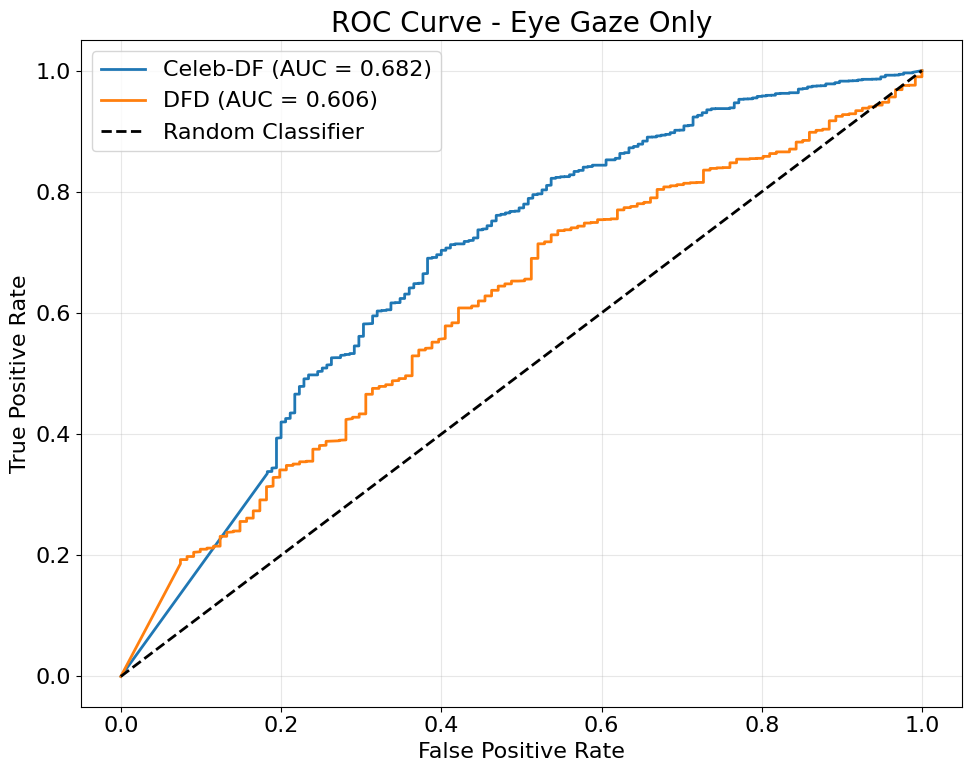

In [1]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, f1_score, recall_score
import matplotlib.pyplot as plt

fps = 30
gaze_features = ['gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z']

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "lines.linewidth": 2
})

def train_gaze_rf(train_real, train_fake):
    li = []
    for files, lab in [(train_real, 0), (train_fake, 1)]:
        for f in files:
            try:
                df = pd.read_csv(f)
                df.columns = df.columns.str.strip()
                if all(c in df.columns for c in gaze_features):
                    temp = df[gaze_features].copy()
                    temp['label'] = lab
                    li.append(temp)
            except: 
                continue
    if not li: 
        return None
    data = pd.concat(li, axis=0, ignore_index=True)
    model = RandomForestClassifier(
        n_estimators=250, 
        max_depth=10, 
        min_samples_split=10, 
        min_samples_leaf=1, 
        max_features='sqrt', 
        random_state=42
    )
    model.fit(data[gaze_features], data['label'])
    return model

def process_dataset(base_real, base_fake, name):
    print(f"\n>>> Processing: {name}...")
    folders = sorted([d for d in os.listdir(base_real) if os.path.isdir(os.path.join(base_real, d))])
    
    y_true, gaze_scores = [], []

    for subj in folders:
        f_real = glob.glob(os.path.join(base_real, subj, "*.csv"))
        f_fake = glob.glob(os.path.join(base_fake, subj, "*.csv"))
        if len(f_real) < 2 or len(f_fake) < 2: 
            continue

        tr_real, te_real = train_test_split(f_real, train_size=0.7, random_state=42)
        tr_fake, te_fake = train_test_split(f_fake, train_size=0.3, random_state=42)

        rf = train_gaze_rf(tr_real, tr_fake)
        if not rf: 
            continue

        for f, lab in [(f, 0) for f in te_real] + [(f, 1) for f in te_fake]:
            try:
                y_true.append(lab)
                df_test = pd.read_csv(f)
                df_test.columns = df_test.columns.str.strip()

                if all(c in df_test.columns for c in gaze_features):
                    g_score = np.mean(rf.predict(df_test[gaze_features]))
                    gaze_scores.append(g_score)
                else:
                    gaze_scores.append(0.0)
            except:
                continue

    if not y_true or not gaze_scores:
        print(f"Could not process data for {name}")
        return None

    y_pred_bin = [1 if s >= 0.5 else 0 for s in gaze_scores]
    
    res = {
        'name': name,
        'auc': roc_auc_score(y_true, gaze_scores),
        'acc': accuracy_score(y_true, y_pred_bin),
        'prec': precision_score(y_true, y_pred_bin, zero_division=0),
        'recall': recall_score(y_true, y_pred_bin, zero_division=0),
        'f1': f1_score(y_true, y_pred_bin, zero_division=0),
        'fpr': None, 
        'tpr': None
    }
    
    res['fpr'], res['tpr'], _ = roc_curve(y_true, gaze_scores)
    return res

path_celeb_real = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/real_celebDF"
path_celeb_fake = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/fake_celebDF"
path_dfd_real = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/real_DFD"
path_dfd_fake = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/fake_DFD"

res_celeb = process_dataset(path_celeb_real, path_celeb_fake, "Celeb-DF")
res_dfd = process_dataset(path_dfd_real, path_dfd_fake, "DFD")

print("\n" + "="*85)
print(f"{'DATASET':<15} | {'ACC':<8} | {'AUC':<8} | {'PRECISION':<10} | {'RECALL':<8} | {'F1':<8}")
print("-" * 85)
for r in [res_celeb, res_dfd]:
    if r:
        print(f"{r['name']:<15} | {r['acc']:.4f} | {r['auc']:.4f} | {r['prec']:.4f}    | {r['recall']:.4f} | {r['f1']:.4f}")
print("="*85)

plt.figure(figsize=(10, 8))
for r in [res_celeb, res_dfd]:
    if r and r['fpr'] is not None:
        plt.plot(r['fpr'], r['tpr'], label=f"{r['name']} (AUC = {r['auc']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Eye Gaze Only')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

micro expressions alone


>>> Processing Celeb-DF...

>>> Processing DFD...
DATASET         | ACC      | AUC      | PRECISION  | RECALL   | F1      
Celeb-DF        | 0.9578 | 0.5287 | 0.9578    | 1.0000 | 0.9784
DFD             | 0.9470 | 0.4900 | 0.9470    | 1.0000 | 0.9728


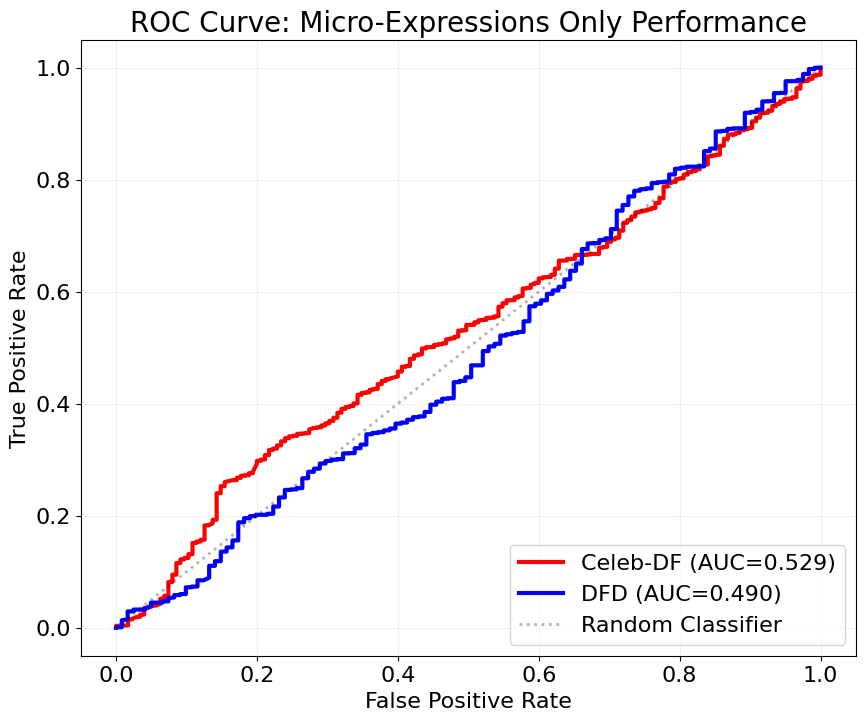

In [2]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.ndimage import label
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, f1_score, recall_score
import matplotlib.pyplot as plt

fps = 30
au_cols = ['au12', 'au6', 'au15', 'au1', 'au4']
gaze_features = ['gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z']

me_weights = {
    'mean_intensity': 4.0,
    'std_intensity': 2.0,
    'frequency': 1.0,
    'max_intensity': 2.0,
    'count': 5.0
}

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "lines.linewidth": 2
})


def get_xy(df, idx):
    return df[f'x_{idx}'], df[f'y_{idx}']

def compute_au12(df):
    x48, y48 = get_xy(df, 48); x54, y54 = get_xy(df, 54)
    x0, _ = get_xy(df, 0); x16, _ = get_xy(df, 16)
    fw = np.abs(x16 - x0).replace(0, np.nan)
    mw = np.abs(x54 - x48) / fw
    _, y30 = get_xy(df, 30)
    lift = -((y48 + y54) / 2 - y30) / fw
    return 0.6 * mw + 0.4 * lift

def compute_au6(df):
    _, y27 = get_xy(df, 27); _, y30 = get_xy(df, 30)
    nl = np.abs(y30 - y27).replace(0, np.nan)
    _, y37 = get_xy(df, 37); _, y38 = get_xy(df, 38)
    _, y40 = get_xy(df, 40); _, y41 = get_xy(df, 41)
    left = ((y40 + y41) / 2) - ((y37 + y38) / 2)
    _, y43 = get_xy(df, 43); _, y44 = get_xy(df, 44)
    _, y46 = get_xy(df, 46); _, y47 = get_xy(df, 47)
    right = ((y46 + y47) / 2) - ((y43 + y44) / 2)
    return -((left + right) / 2) / nl

def compute_au15(df):
    _, y27 = get_xy(df, 27); _, y30 = get_xy(df, 30)
    nl = np.abs(y30 - y27).replace(0, np.nan)
    _, y48 = get_xy(df, 48); _, y54 = get_xy(df, 54)
    return ((y48 + y54) / 2 - y30) / nl

def compute_au1(df):
    _, y21 = get_xy(df, 21); _, y22 = get_xy(df, 22)
    _, y27 = get_xy(df, 27); _, y30 = get_xy(df, 30)
    val = (y27 - (y21 + y22) / 2) / np.abs(y30 - y27).replace(0, np.nan)
    return np.maximum(0, val)

def compute_au4(df):
    x21, _ = get_xy(df, 21); x22, _ = get_xy(df, 22)
    x0, _ = get_xy(df, 0); x16, _ = get_xy(df, 16)
    face_width = np.abs(x16 - x0).replace(0, np.nan)
    
    brow_gap = np.abs(x22 - x21) / face_width
    return 1.0 - brow_gap

def z_normalize(df, col):
    smooth = df[col].rolling(3, center=True).mean()
    
    rolling_baseline = smooth.rolling(int(2 * fps), center=True, min_periods=1).median()
    
    delta = smooth - rolling_baseline
    
    return (delta - delta.mean()) / delta.std() if delta.std() != 0 else delta * 0

def extract_events(active_mask, df, peak_cols):
    events = []
    labeled, num = label(active_mask)
    for i in range(1, num + 1):
        idx = np.where(labeled == i)[0]
        if 0.1 <= (len(idx) / fps) <= 0.5:
            events.append(float(df.loc[idx, peak_cols].max().max()))
    return events

def get_microexpression_features(path):
    try:
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        df['au12'] = compute_au12(df); df['au6'] = compute_au6(df)
        df['au15'] = compute_au15(df); df['au1'] = compute_au1(df); df['au4'] = compute_au4(df)
        for au in au_cols: df[f'{au}_z'] = z_normalize(df, au)
        h = (df['au12_z'] > 2.0) & (df['au6_z'] > 1.5)
        s = (df['au15_z'] > 2.0) & ((df['au1_z'] > 1.5) | (df['au4_z'] > 1.5))
        peaks = extract_events(h, df, ['au12_z', 'au6_z']) + extract_events(s, df, ['au15_z', 'au1_z', 'au4_z'])
        return {
            'mean_intensity': np.mean(peaks) if peaks else 0.0,
            'max_intensity': np.max(peaks) if peaks else 0.0,
            'std_intensity': np.std(peaks) if peaks else 0.0,
            'count': len(peaks),
            'frequency': len(peaks) / (len(df) / fps) if len(df) > 0 else 0.0
        }
    except: return None

def train_gaze_rf(train_real, train_fake):
    li = []
    for files, lab in [(train_real, 0), (train_fake, 1)]:
        for f in files:
            try:
                df = pd.read_csv(f)
                df.columns = df.columns.str.strip()
                if all(c in df.columns for c in gaze_features):
                    temp = df[gaze_features].copy()
                    temp['label'] = lab
                    li.append(temp)
            except: continue
    if not li: return None
    data = pd.concat(li, axis=0, ignore_index=True)
    model = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
    model.fit(data[gaze_features], data['label'])
    return model

def learn_me_baseline(train_files):
    feats = [get_microexpression_features(f) for f in train_files]
    feats = [f for f in feats if f]
    if not feats: return None
    return {k: {'mean': np.mean([f[k] for f in feats]), 'std': np.std([f[k] for f in feats])} for k in feats[0].keys()}

def compute_me_distance(features, baseline):
    if not features or not baseline: return 10.0
    dist = 0.0
    for k, w in me_weights.items():
        if k in features:
            mu, sig = baseline[k]['mean'], max(0.1, baseline[k]['std'])
            dist += (abs(features[k] - mu) / sig) * w
    return dist

def process_dataset(base_real, base_fake, name):
    print(f"\n>>> Processing {name}...")
    folders = sorted([d for d in os.listdir(base_real) if os.path.isdir(os.path.join(base_real, d))])
    
    y_true, me_scores = [], []

    for subj in folders:
        f_real = glob.glob(os.path.join(base_real, subj, "*.csv"))
        f_fake = glob.glob(os.path.join(base_fake, subj, "*.csv"))
        if len(f_real) < 2 or len(f_fake) < 2: continue

        tr_real, te_real = train_test_split(f_real, train_size=0.7, random_state=42)
        tr_fake, te_fake = train_test_split(f_fake, train_size=0.3, random_state=42)

        me_base = learn_me_baseline(tr_real)
        if not me_base: continue

        dists_tr = [compute_me_distance(get_microexpression_features(f), me_base) for f in tr_real]
        me_thresh = max(2.0, np.percentile(dists_tr, 95)) if dists_tr else 3.0

        for f, lab in [(f, 0) for f in te_real] + [(f, 1) for f in te_fake]:
            y_true.append(lab)
            
            me_feat = get_microexpression_features(f)
            dist = compute_me_distance(me_feat, me_base)
            me_score = 1 / (1 + np.exp(-(dist / me_thresh)))
            
            me_scores.append(me_score)

    y_pred_bin = [1 if s >= 0.5 else 0 for s in me_scores]
    
    res = {
        'name': name,
        'auc': roc_auc_score(y_true, me_scores),
        'acc': accuracy_score(y_true, y_pred_bin),
        'prec': precision_score(y_true, y_pred_bin, zero_division=0),
        'recall': recall_score(y_true, y_pred_bin, zero_division=0),
        'f1': f1_score(y_true, y_pred_bin, zero_division=0),
        'fpr_me': None, 'tpr_me': None
    }
    
    res['fpr_me'], res['tpr_me'], _ = roc_curve(y_true, me_scores)
    
    return res

path_celeb_real = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/real_celebDF"
path_celeb_fake = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/fake_celebDF"
path_dfd_real = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/real_DFD"
path_dfd_fake = "/Users/andreeabrad/StudioCode/micro-expressions/datasets/fake_DFD"

res_celeb = process_dataset(path_celeb_real, path_celeb_fake, "Celeb-DF")
res_dfd = process_dataset(path_dfd_real, path_dfd_fake, "DFD")

print(f"{'DATASET':<15} | {'ACC':<8} | {'AUC':<8} | {'PRECISION':<10} | {'RECALL':<8} | {'F1':<8}")
for r in [res_celeb, res_dfd]:
    print(f"{r['name']:<15} | {r['acc']:.4f} | {r['auc']:.4f} | {r['prec']:.4f}    | {r['recall']:.4f} | {r['f1']:.4f}")

plt.figure(figsize=(10, 8))
plt.plot(res_celeb['fpr_me'], res_celeb['tpr_me'], 'r-', linewidth=3, label=f"Celeb-DF (AUC={res_celeb['auc']:.3f})")
plt.plot(res_dfd['fpr_me'], res_dfd['tpr_me'], 'b-', linewidth=3, label=f"DFD (AUC={res_dfd['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k:', alpha=0.3, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Micro-Expressions Only Performance")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()